# How well does the detector work on a work it has never seen?

The preceding notebooks report what the detectors found on this corpus and what a reviewer
confirmed. Neither answers the question an evaluator asks next: does this transfer to a work the
model was not trained on, and how much does it miss?

The chapter originally answered that with a held-out validation split. This notebook shows why
that answer was invalid, replaces it with leave-one-work-out cross-validation over 208 trained
models, and then asks two further questions the chapter had never put: whether the detector was
too small, and whether any of these numbers survive a change of random seed.

The last of those turns out to matter more than the rest.

---

**Reads** `4_detection_outputs/fleuron_*_v1/` (the original splits) and `fleuron_*_lowo*`
(the cross-validation runs) · **Writes** `4_detection_outputs/validation/` ·
**Chapter README** §5

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

NOTEBOOK_DIR = Path.cwd().resolve()
assert NOTEBOOK_DIR.name == '4_detection', 'Run this notebook from its own folder, 4_detection/.'
PROJECT_DIR = NOTEBOOK_DIR.parent
CORPUS_DIR = PROJECT_DIR.parent
OUTPUTS = PROJECT_DIR/'4_detection_outputs'
IMAGE_DIRS = {'original': CORPUS_DIR/'Images', 'suppl': CORPUS_DIR/'images suppl'}
sys.path.insert(0, str(PROJECT_DIR))
from book_identifiers import build_work_map, volume_id

RUN_TAG = ''
ALLOW_OVERWRITE = False
OUT = OUTPUTS/f'validation{RUN_TAG}'

IOU_EVAL = 0.50
CONF = 0.25
INK, FOIL, RULE, FLAG = '#444444', '#b0b7bd', '#b23a3a', '#1f4e79'
TARGETS = ['Fleuron_2', 'Fleuron_74', 'Fleuron_73', 'Fleuron_72']
TRAIN_BOX_RANGE = {'Fleuron_2': '169–264', 'Fleuron_74': '78–96',
                   'Fleuron_73': '119–365', 'Fleuron_72': '427–675'}
TRAIN_BOX_MEDIAN = {'Fleuron_2': 259, 'Fleuron_74': 93,
                    'Fleuron_73': 362.5, 'Fleuron_72': 647}
print('targets:', ', '.join(TARGETS))

targets: Fleuron_2, Fleuron_74, Fleuron_73, Fleuron_72


## 1. The original validation split did not hold out what it claimed to

Two separate defects, found by auditing the dataset directories on disk rather than by reading
the code that wrote them.

**Sibling volumes were treated as different books.** The split grouped scans by a prefix taken
from the filename. `vaoe1`, `vaoe2`, `vaoe3` and `vaoe4` are four volumes of one work, printed
in the same shop from the same ornament stock, so holding out volume 1 while training on
volume 2 does not test generalisation to an unseen work. `book_identifiers.py` distinguishes
the two levels; the split did not use it.

**One target trained on its own validation set.** The build script wrote into the dataset
directory without clearing it, and skipped files already present. `Fleuron_73`'s directory was
written twice, one minute apart, under two different split rules; scans the first pass placed
in `train/` survived into the second, which placed the same scans in `val/`.

The cell below recounts both from the directories as they stand.

In [2]:
manifest = pd.read_csv(PROJECT_DIR/'all_regions_outputs'/'features'/'features_manifest.csv')
manifest['volume'] = manifest.rel_path.map(volume_id)
work_of, multivolume = build_work_map(sorted(manifest.volume.unique()))
manifest['work'] = manifest.volume.map(work_of)
work_of_scan = manifest.drop_duplicates('stem').set_index('stem').work.to_dict()

rows = []
for target in TARGETS:
    root = OUTPUTS/f'{target.lower()}_v1'
    train = {p.stem for p in (root/'images'/'train').iterdir()}
    val = {p.stem for p in (root/'images'/'val').iterdir()}
    train_works = {work_of_scan[s] for s in train}
    val_boxes = leaked = 0
    for lbl in (root/'labels'/'val').glob('*.txt'):
        n = len([x for x in lbl.read_text().splitlines() if x.strip()])
        val_boxes += n
        if work_of_scan[lbl.stem] in train_works:
            leaked += n
    rows.append(dict(target=target, val_boxes=val_boxes, in_a_training_work=leaked,
                     genuinely_unseen=val_boxes - leaked,
                     scans_in_both_splits=len(train & val)))
audit = pd.DataFrame(rows)
print(audit.to_string(index=False))
print('\nmulti-volume sets responsible:')
for w, members in multivolume.items():
    if w in {'vaoelhgo1760', 'aujam1760', 'lmfaut1760'}:
        print(f'  {w}: {", ".join(members)}')

    target  val_boxes  in_a_training_work  genuinely_unseen  scans_in_both_splits
 Fleuron_2         79                  75                 4                     0
Fleuron_74         16                   0                16                     0
Fleuron_73         78                  76                 2                     5
Fleuron_72        139                  72                67                     0

multi-volume sets responsible:
  aujam1760: auj1am1760, auj2am1760
  lmfaut1760: lmfa1ut1760, lmfa2ut1760
  vaoelhgo1760: vaoe1lhgo1760, vaoe2lhgo1761, vaoe3lhgo1761, vaoe4lhgo1761


Three of the four splits are contaminated, and the fourth rests on 16 instances. Whatever
those validation figures measured, it was not generalisation to an unseen work.

**None of this touches the chapter's result.** The 702 confirmed recoveries come from a human
reviewing crops, not from a metric, and a broken validation split cannot make a confirmed
impression unconfirmed.

## 2. Why a single split cannot fix it

Rebuilding the split correctly was tried first and failed, for a reason worth reporting.
`Fleuron_73`'s impressions are concentrated: two thirds of them are in one work. A random 20%
of works held out leaves a validation set of seven instances; holding out the dominant work
instead removes two thirds of the training data. Neither measures anything.

In [3]:
conc = []
for target in TARGETS:
    lowo = OUTPUTS/f'{target.lower()}_lowo'
    truth = pd.read_csv(lowo/'pooled_ground_truth.csv')
    share = truth.fold.value_counts(normalize=True)
    conc.append(dict(target=target, works=truth.fold.nunique(), impressions=len(truth),
                     largest_work=share.index[0], largest_share=round(share.iloc[0], 3)))
print(pd.DataFrame(conc).to_string(index=False))

# The number of models this chapter trained, counted from the fold tables on disk rather than
# quoted in prose. One fold is one model trained from scratch, and the count is the figure the
# README reports, so it must not be maintained by hand in two places.
CONFIGS = {'_lowo': 'yolo11n, seed 42', '_lowo_seed1': 'yolo11n, seed 1',
           '_lowo_seed2': 'yolo11n, seed 2', '_lowo_s': 'yolo11s, seed 42'}
folds = []
for tag, label in CONFIGS.items():
    n = sum(len(pd.read_csv(OUTPUTS/f'{t.lower()}{tag}'/'folds.csv')) for t in TARGETS)
    folds.append(dict(configuration=label, folds=n))
folds = pd.DataFrame(folds)
N_MODELS = int(folds.folds.sum())
print(f'\n{folds.folds.iloc[0]} folds per pass over the four targets:')
print(folds.to_string(index=False))
print(f'\n{N_MODELS} models trained in total.')

    target  works  impressions largest_work  largest_share
 Fleuron_2     17          265 vaoelhgo1760          0.362
Fleuron_74     12           98   vohigecr60          0.204
Fleuron_73     14          366   dicolosn73          0.675
Fleuron_72      9          678   dicolosn73          0.370

52 folds per pass over the four targets:
   configuration  folds
yolo11n, seed 42     52
 yolo11n, seed 1     52
 yolo11n, seed 2     52
yolo11s, seed 42     52

208 models trained in total.


## 3. Leave-one-work-out

Each work is held out in turn and a detector is trained from scratch on the rest, so every
impression is predicted exactly once by a model that never saw its work. Predictions are pooled
across folds and scored by greedy, confidence-ordered matching at IoU 0.50, one prediction to at
most one impression: the rule the candidate-extraction benchmark uses, so the two stages can be
read against each other.

Training is done by `_tools/leave_one_work_out.py`, which writes a checkpoint per fold. This
notebook reads those outputs and does all scoring itself, so the tables below cannot drift from
the stored predictions.

**Two averages are reported and they answer different questions.** Impression-weighted recall
treats every impression equally, so a work holding 247 of 366 impressions dominates.
Work-weighted recall treats every work equally, which is the question "will this transfer to a
book the model has not seen". They diverge sharply exactly where the design is concentrated.

In [4]:
def iou(a, b):
    ix1, iy1 = max(a[0], b[0]), max(a[1], b[1])
    ix2, iy2 = min(a[2], b[2]), min(a[3], b[3])
    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    union = (a[2]-a[0])*(a[3]-a[1]) + (b[2]-b[0])*(b[3]-b[1]) - inter
    return inter/union if union > 0 else 0.0


def match(pred, truth, conf=CONF):
    """Return tp, fp, fn and the set of ground-truth indices that were found."""
    tp = fp = 0
    claimed = set()
    by_scan = {k: g for k, g in truth.groupby('stem')} if len(truth) else {}
    sel = pred[pred.conf >= conf] if len(pred) else pred
    for r in (sel.sort_values('conf', ascending=False).itertuples() if len(sel) else []):
        best, best_i = 0.0, None
        for g in by_scan.get(r.stem, pd.DataFrame()).itertuples():
            if g.Index in claimed:
                continue
            v = iou((r.x1, r.y1, r.x2, r.y2), (g.x1, g.y1, g.x2, g.y2))
            if v > best:
                best, best_i = v, g.Index
        if best >= IOU_EVAL:
            tp += 1
            claimed.add(best_i)
        else:
            fp += 1
    return tp, fp, len(truth) - tp, claimed


def evaluate(run, conf=CONF):
    d = OUTPUTS/run
    if not (d/'pooled_predictions.csv').exists():
        return None
    pred = pd.read_csv(d/'pooled_predictions.csv')
    truth = pd.read_csv(d/'pooled_ground_truth.csv').reset_index(drop=True)
    tp, fp, fn, _ = match(pred, truth, conf)
    per_fold = []
    for w in sorted(truth.fold.unique()):
        t2 = truth[truth.fold == w]
        a, b, c, _ = match(pred[pred.fold == w], t2, conf)
        per_fold.append(a/len(t2) if len(t2) else np.nan)
    return dict(tp=tp, fp=fp, fn=fn,
                precision=tp/(tp+fp) if tp+fp else 0.0,
                recall=tp/(tp+fn) if tp+fn else 0.0,
                recall_by_work=float(np.nanmean(per_fold)),
                impressions=len(truth))


base = []
for target in TARGETS:
    r = evaluate(f'{target.lower()}_lowo')
    base.append(dict(target=target, train_box_range=TRAIN_BOX_RANGE[target], **r))
base = pd.DataFrame(base)
print(base[['target', 'train_box_range', 'impressions', 'tp', 'fp', 'fn',
            'precision', 'recall', 'recall_by_work']].round(3).to_string(index=False))

    target train_box_range  impressions  tp  fp  fn  precision  recall  recall_by_work
 Fleuron_2         169–264          265 229  62  36      0.787   0.864           0.857
Fleuron_74           78–96           98  93  78   5      0.544   0.949           0.929
Fleuron_73         119–365          366 178  47 188      0.791   0.486           0.778
Fleuron_72         427–675          678 561 203 117      0.734   0.827           0.818


## 4. What the detector misses

Every ground-truth impression is either found or not by the model that never saw its work. If
the missed ones look like the found ones, then failure is a property of the work rather than of
the impression, and there is no "hard impression" to characterise.

In [5]:
# Scan dimensions, read from the image headers. A test on x1/y1 alone can only see the left
# and top edges; every impression that touches an edge in this corpus touches a right or
# bottom one, so the earlier two-sided test could not have observed any of them.
scan_size = {}
for r in manifest.drop_duplicates('stem').itertuples():
    p = IMAGE_DIRS[r.source]/r.rel_path
    if p.exists():
        scan_size[r.stem] = Image.open(p).size

missed = []
for target in TARGETS:
    d = OUTPUTS/f'{target.lower()}_lowo'
    pred = pd.read_csv(d/'pooled_predictions.csv')
    truth = pd.read_csv(d/'pooled_ground_truth.csv').reset_index(drop=True)
    _, _, _, found = match(pred, truth)
    truth['target'] = target
    truth['found'] = truth.index.isin(found)
    truth['min_side'] = np.minimum(truth.x2 - truth.x1, truth.y2 - truth.y1)
    truth['area'] = (truth.x2 - truth.x1) * (truth.y2 - truth.y1)
    truth['per_scan'] = truth.groupby('stem').stem.transform('size')
    truth['scan_w'] = truth.stem.map(lambda s: scan_size[s][0])
    truth['scan_h'] = truth.stem.map(lambda s: scan_size[s][1])
    truth['clipped'] = ((truth.x1 <= 1) | (truth.y1 <= 1)
                        | (truth.x2 >= truth.scan_w - 1) | (truth.y2 >= truth.scan_h - 1))
    missed.append(truth)
M = pd.concat(missed, ignore_index=True)

comp = M.groupby('found').agg(n=('found', 'size'), median_min_side=('min_side', 'median'),
                              median_area=('area', 'median'),
                              median_per_scan=('per_scan', 'median'),
                              clipped=('clipped', 'sum'))
print('found against missed, pooled over all four targets:')
print(comp.round(1).to_string())
print(f"\nimpressions touching a scan edge: {int(M.clipped.sum())} of {len(M)}, "
      f"of which found: {int(M[M.clipped].found.sum())}")

# Quartiles are taken within each target, not across the pool. The four designs differ in
# typical size, so pooled quartiles would confound "small impressions are missed" with
# "the target whose impressions are small is harder", which are different claims.
print('\nmiss rate by size quartile, computed within each target:')
rows = []
for t, g in M.groupby('target'):
    g = g.copy()
    g['q'] = pd.qcut(g.min_side, 4, labels=['Q1 smallest', 'Q2', 'Q3', 'Q4 largest'],
                     duplicates='drop')
    r = g.groupby('q', observed=True).found.agg(['size', 'sum'])
    rows.append(dict(target=t, median_px=round(g.min_side.median()),
                     **{str(q): round(1 - r.loc[q, 'sum']/r.loc[q, 'size'], 3)
                        for q in r.index}))
size_effect = pd.DataFrame(rows)
print(size_effect.to_string(index=False))

found against missed, pooled over all four targets:
          n  median_min_side  median_area  median_per_scan  clipped
found                                                              
False   346             45.0       3082.0             19.0        1
True   1061             51.0       2805.0             17.0       10

impressions touching a scan edge: 11 of 1407, of which found: 10

miss rate by size quartile, computed within each target:
    target  median_px  Q1 smallest    Q2    Q3  Q4 largest
 Fleuron_2         66        0.313 0.164 0.031       0.030
Fleuron_72         48        0.510 0.045 0.026       0.000
Fleuron_73         48        0.465 0.532 0.590       0.441
Fleuron_74         64        0.000 0.182 0.036       0.000


## 5. Was the detector too small?

Every result above uses `yolo11n`, the smallest model in the family, chosen without comparison.
The whole cross-validation was repeated with `yolo11s` to test whether capacity was the limit.

In [6]:
cap = []
for target in TARGETS:
    n = evaluate(f'{target.lower()}_lowo')
    s = evaluate(f'{target.lower()}_lowo_s')
    if s is None:
        continue
    cap.append(dict(target=target, train_box_range=TRAIN_BOX_RANGE[target],
                    train_boxes_median=TRAIN_BOX_MEDIAN[target],
                    n_P=n['precision'], n_R=n['recall'],
                    s_P=s['precision'], s_R=s['recall'],
                    delta_R=s['recall'] - n['recall'],
                    delta_P=s['precision'] - n['precision']))
cap = pd.DataFrame(cap).sort_values('train_boxes_median')
print(cap.round(3).to_string(index=False))

    target train_box_range  train_boxes_median   n_P   n_R   s_P   s_R  delta_R  delta_P
Fleuron_74           78–96                93.0 0.544 0.949 0.417 0.745   -0.204   -0.127
 Fleuron_2         169–264               259.0 0.787 0.864 0.711 0.947    0.083   -0.076
Fleuron_73         119–365               362.5 0.791 0.486 0.681 0.757    0.270   -0.111
Fleuron_72         427–675               647.0 0.734 0.827 0.511 0.978    0.150   -0.224


Read alone, that table says a larger model raises recall on three targets and lowers it on the
one with the least training data, and lowers precision everywhere. It is tempting to conclude
that the chapter undersized its detector.

**Section 6 shows that conclusion does not survive.**

## 6. How much does a random seed move these numbers?

Nothing in the chapter had ever been run twice. The entire cross-validation was repeated with
two further seeds, which reseed both the negative-scan sample and the training initialisation,
so the spread below is the variance of the whole procedure rather than of the optimiser alone.

In [7]:
seed_rows = []
for target in TARGETS:
    vals = []
    for tag in ['_lowo', '_lowo_seed1', '_lowo_seed2']:
        r = evaluate(f'{target.lower()}{tag}')
        if r:
            vals.append(r)
    if len(vals) < 2:
        continue
    P = [v['precision'] for v in vals]
    R = [v['recall'] for v in vals]
    B = [v['recall_by_work'] for v in vals]
    seed_rows.append(dict(target=target, seeds=len(vals),
                          P_min=min(P), P_max=max(P), P_spread=max(P)-min(P),
                          R_min=min(R), R_max=max(R), R_spread=max(R)-min(R),
                          work_R_spread=max(B)-min(B)))
seeds = pd.DataFrame(seed_rows)
print(seeds.round(3).to_string(index=False))

    target  seeds  P_min  P_max  P_spread  R_min  R_max  R_spread  work_R_spread
 Fleuron_2      3  0.772  0.797     0.025  0.864  0.947     0.083          0.051
Fleuron_74      3  0.544  0.825     0.281  0.847  0.949     0.102          0.012
Fleuron_73      3  0.791  0.857     0.065  0.481  0.571     0.090          0.117
Fleuron_72      3  0.690  0.764     0.074  0.765  0.963     0.198          0.159


## 7. The capacity effect against the seed effect

The comparison that decides whether §5 says anything. A difference between two models means
nothing if simply rerunning one of them with a different seed moves it as far.

In [8]:
verdict = cap.merge(seeds[['target', 'R_spread']], on='target')
verdict['ratio'] = (verdict.delta_R.abs()/verdict.R_spread).round(2)
verdict['verdict'] = np.where(verdict.ratio >= 2, 'exceeds seed noise',
                     np.where(verdict.ratio >= 1, 'comparable to seed noise',
                              'WITHIN seed noise'))
print(verdict[['target', 'train_box_range', 'R_spread', 'delta_R', 'ratio',
               'verdict']].round(3).to_string(index=False))

    target train_box_range  R_spread  delta_R  ratio                  verdict
Fleuron_74           78–96     0.102   -0.204   2.00       exceeds seed noise
 Fleuron_2         169–264     0.083    0.083   1.00 comparable to seed noise
Fleuron_73         119–365     0.090    0.270   3.00       exceeds seed noise
Fleuron_72         427–675     0.198    0.150   0.76        WITHIN seed noise


**Only `Fleuron_73` shows a capacity gain clearly larger than the noise, and `Fleuron_74`
shows a capacity *loss* of the same standing.** On the other two the difference between model
sizes is the size of the wobble between two runs of the same model.

Three conclusions follow, and the third is the one that matters for the rest of the chapter.

1. A larger detector is not uniformly better here, and the chapter's use of `yolo11n` is not a
   defect that inflates or deflates its result.
2. Where a target has very little training data (`Fleuron_74`, 82 boxes), the larger model is
   worse, which is the expected direction for overfitting but rests on a single run.
3. **Run-to-run variation on this task reaches 0.2 in recall and 0.28 in precision.** No single
   run supports a comparison finer than that. This applies to every detection number in the
   chapter, including those reported before this notebook existed, and it is why the results
   above are given with spreads rather than as point estimates.

## 8. Choosing an operating point

Every figure in the chapter uses a confidence threshold of 0.25 and nothing chose it. The sweep
below shows what the threshold buys and spends. Because the stage exists to *recover* impressions
that no other method can reach, and because a human confirms every proposal before it enters the
catalogue, recall is worth more than precision here: a false proposal costs a moment's review,
a missed impression is lost silently. That argues for a low threshold, and the sweep shows what
the choice costs.

In [9]:
sweep = []
for target in TARGETS:
    for c in [0.25, 0.35, 0.50, 0.65, 0.80]:
        r = evaluate(f'{target.lower()}_lowo', conf=c)
        sweep.append(dict(target=target, conf=c, precision=r['precision'], recall=r['recall'],
                          f2=(5*r['precision']*r['recall']/(4*r['precision']+r['recall']))
                          if (r['precision']+r['recall']) else 0.0))
sweep = pd.DataFrame(sweep)
print(sweep.pivot(index='conf', columns='target',
                  values=['precision', 'recall']).round(3).to_string())
print('\nF2 (recall weighted four times precision), the extraction benchmark\'s metric:')
print(sweep.pivot(index='conf', columns='target', values='f2').round(3).to_string())

       precision                                     recall                                 
target Fleuron_2 Fleuron_72 Fleuron_73 Fleuron_74 Fleuron_2 Fleuron_72 Fleuron_73 Fleuron_74
conf                                                                                        
0.25       0.787      0.734      0.791      0.544     0.864      0.827      0.486      0.949
0.35       0.813      0.760      0.828      0.587     0.838      0.799      0.355      0.827
0.50       0.837      0.774      0.895      0.643     0.811      0.767      0.186      0.755
0.65       0.838      0.800      0.918      0.714     0.762      0.683      0.123      0.663
0.80       0.865      0.867      0.900      0.733     0.679      0.479      0.049      0.561

F2 (recall weighted four times precision), the extraction benchmark's metric:
target  Fleuron_2  Fleuron_72  Fleuron_73  Fleuron_74
conf                                                 
0.25        0.848       0.807       0.527       0.826
0.35        0.8

## 9. Figure

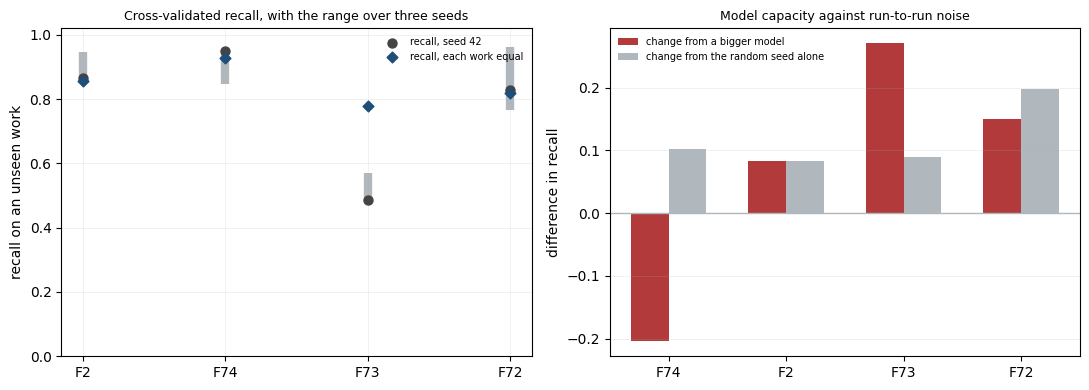

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
x = np.arange(len(base))
for i, row in base.iterrows():
    s = seeds[seeds.target == row.target]
    if len(s):
        ax.vlines(i, s.R_min.iloc[0], s.R_max.iloc[0], color=FOIL, lw=6, zorder=1)
ax.scatter(x, base.recall, color=INK, zorder=3, s=42, label='recall, seed 42')
ax.scatter(x, base.recall_by_work, color=FLAG, marker='D', zorder=3, s=30,
           label='recall, each work equal')
ax.set_xticks(x)
ax.set_xticklabels([t.replace('Fleuron_', 'F') for t in base.target])
ax.set_ylim(0, 1.02)
ax.set_ylabel('recall on an unseen work')
ax.set_title('Cross-validated recall, with the range over three seeds', fontsize=9)
ax.legend(fontsize=7, frameon=False)
ax.grid(alpha=0.25, lw=0.5)

ax = axes[1]
ax.axhline(0, color=FOIL, lw=1)
ax.bar(np.arange(len(verdict)) - 0.16, verdict.delta_R, width=0.32, color=RULE,
       label='change from a bigger model')
ax.bar(np.arange(len(verdict)) + 0.16, verdict.R_spread, width=0.32, color=FOIL,
       label='change from the random seed alone')
ax.set_xticks(np.arange(len(verdict)))
ax.set_xticklabels([t.replace('Fleuron_', 'F') for t in verdict.target])
ax.set_ylabel('difference in recall')
ax.set_title('Model capacity against run-to-run noise', fontsize=9)
ax.legend(fontsize=7, frameon=False)
ax.grid(alpha=0.25, lw=0.5, axis='y')

fig.tight_layout()
plt.show()

In [11]:
def guarded_mkdir(path):
    """Create an output directory, refusing to overwrite a populated one."""
    if path.exists() and any(path.iterdir()) and not (RUN_TAG or ALLOW_OVERWRITE):
        raise RuntimeError(f'{path} already contains results. Set RUN_TAG to write elsewhere, '
                           f'or ALLOW_OVERWRITE = True to replace them.')
    path.mkdir(parents=True, exist_ok=True)
    return path


guarded_mkdir(OUT)
audit.to_csv(OUT/'split_audit.csv', index=False)
base.to_csv(OUT/'cross_validation.csv', index=False)
cap.to_csv(OUT/'capacity.csv', index=False)
seeds.to_csv(OUT/'seed_stability.csv', index=False)
verdict.to_csv(OUT/'capacity_vs_noise.csv', index=False)
sweep.to_csv(OUT/'operating_point.csv', index=False)
M.to_csv(OUT/'impression_outcomes.csv', index=False)
fig.savefig(OUT/'validation.png', dpi=200, bbox_inches='tight')
print('written to', OUT.relative_to(PROJECT_DIR))

written to 4_detection_outputs/validation


## 10. What this notebook establishes

**The chapter's original validation figures are withdrawn.** Three of four splits scored models
on works they had trained on, and the fourth rested on 16 instances.

**Replaced by cross-validation over 208 trained models**, 52 folds repeated for three seeds of
`yolo11n` and once for `yolo11s`, in which every impression is predicted by a model that never
saw its work. Recall on an unseen work ranges from roughly 0.5 to 0.95 across the four designs.

**The detector is not systematically undersized.** A larger model helps one target, hurts
another, and makes no difference beyond noise on the rest.

**Run-to-run variation is the dominant source of uncertainty**, reaching 0.2 in recall. This is
the finding with the widest consequence, because it bounds every comparison the chapter makes
between one detector and another, and it was not measurable before this notebook.

**What it does not establish.** Cross-validated recall estimates recovery of known catalogue
impressions in an unseen work; it is not a bound on the unknown recall of corpus-run models.
The capacity
comparison rests on one seed per model size, so it bounds the seed noise on the smaller model
only.